# __Foci Detection Project__

This notebook goes through all the necessary steps to detect DNA damage in cell nuclei, called Foci.

1. __Dataset Exploration:__ Examining the dataset, visualizing images, and analyzing their properties
2. __Data Preprocessing:__ Setting up preprocessing pipelines
3. __Process Images:__ Setting up a region growing workflow to detect cell nuclei in images.



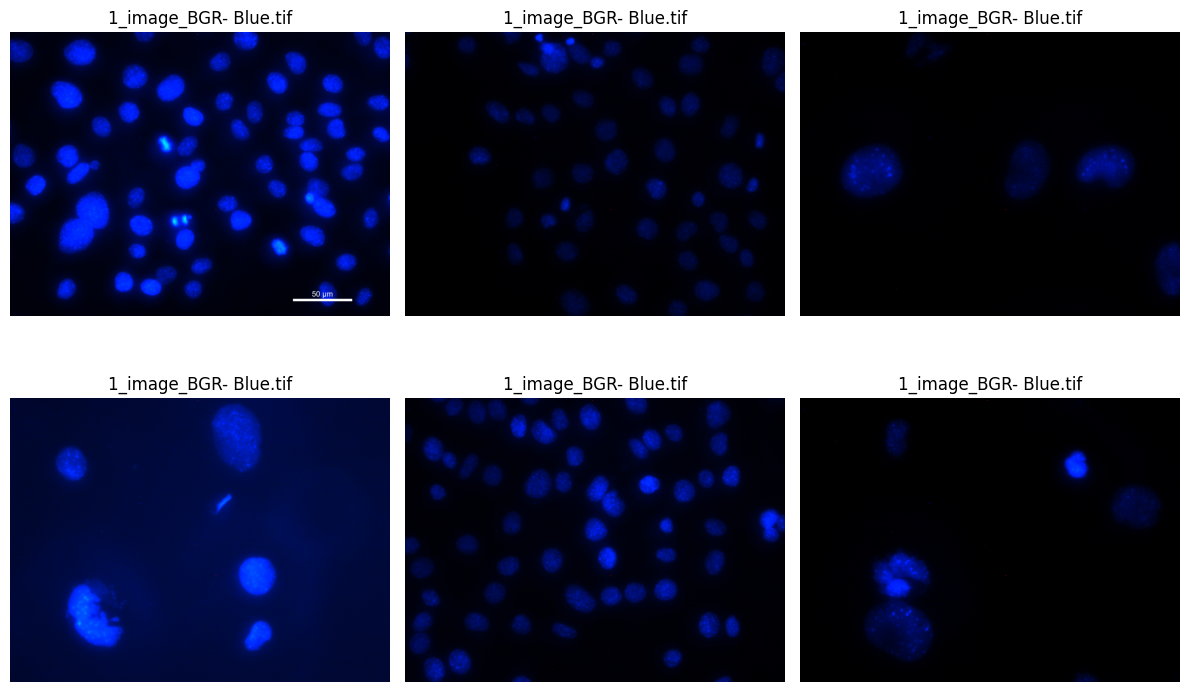

In [28]:
#import
import matplotlib.pyplot as plt
import random
from pathlib import Path
from PIL import Image

root = "data"

imgs = list(Path(root).rglob("*Blue.tif"))  # full paths
sampled = random.sample(imgs, 6)

plt.figure(figsize=(12, 8))
for i, img_path in enumerate(sampled, 1):
    img = Image.open(str(img_path))     # open directly
    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.name)

plt.tight_layout()
plt.show()


As we can see, the nuclei vary in count, size and intensitiy. This creates some challanges:
- Wide variation in nucleus size (tiny to very large) makes fixed-scale detection unreliable.
- Large differences in intensity and contrast hinder thresholding and consistent segmentation.
- Variable cell density causes problems in both sparse and highly crowded regions.
- Overlapping or touching nuclei make instance separation difficult.
- Shape variability (round, elongated, irregular, fragmented) breaks shape-based assumptions.
- Noise, artifacts, and uneven illumination can mimic nuclei or obscure true ones.
- Staining variability across experiments or labs reduces model generalization.
- Domain shifts between microscopes, magnifications, or imaging protocols.
- Low contrast nuclei blend into the background.
- Ambiguous boundaries due to blur or imaging limitations.
- Limited or inconsistent annotations, especially in dense clusters.
- Scale changes between datasets (different pixel sizes or resolutions).

Overall intensity range: 0 - 255
Number of images: 33
Total pixels: 47773440


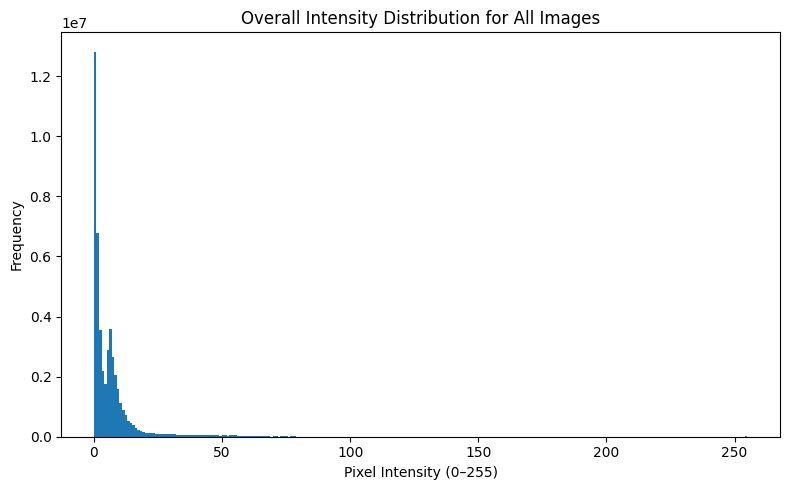

In [9]:
# ---Quick EDA---
# Image Intensity

import numpy as np

def plot_overall_intensity_histogram(root="data"):

    all_pixels = []

    # Load intensities from every image
    for img_path in imgs:
        img = Image.open(str(img_path)).convert("L")   # grayscale
        arr = np.array(img).ravel()
        all_pixels.append(arr)

    # Flatten into one big 1D array
    all_pixels = np.concatenate(all_pixels)

    print("Overall intensity range:", all_pixels.min(), "-", all_pixels.max())
    print("Number of images:", len(imgs))
    print("Total pixels:", len(all_pixels))

    # Combined histogram
    plt.figure(figsize=(8, 5))
    plt.hist(all_pixels, bins=256)
    plt.title("Overall Intensity Distribution for All Images")
    plt.xlabel("Pixel Intensity (0–255)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

plot_overall_intensity_histogram("data")



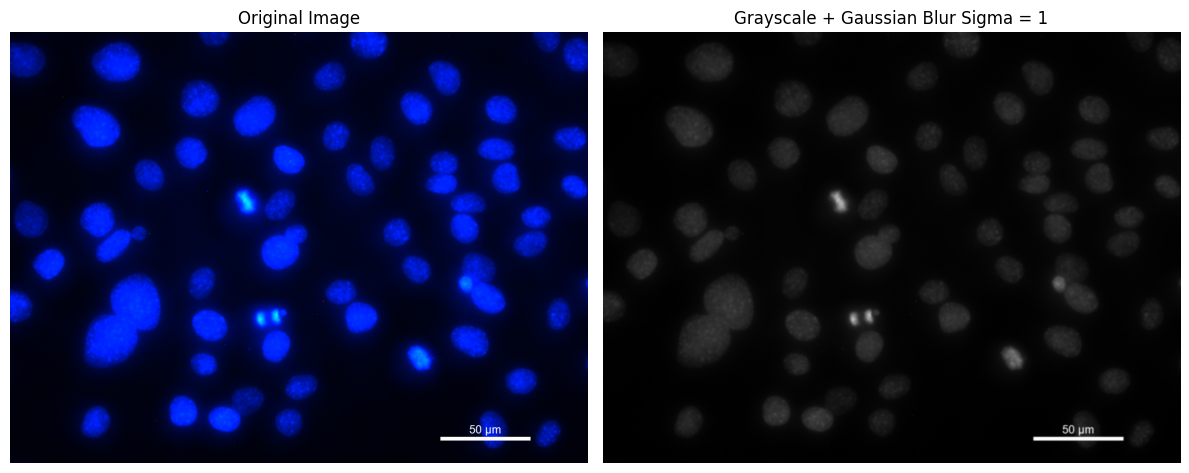

In [29]:
# Data Preprocessing
#- Grayscale
#- Gaussian blurr

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io, filters, measure, color

original_image = io.imread(str(sampled[0]))

# Grayscale Conversion
if original_image.ndim == 3:
    # This result is a 2D float array (0.0 to 1.0)
    grayscale_image = color.rgb2gray(original_image)
else:
    # If the image is already 2D (grayscale), use it directly
    grayscale_image = original_image

# Gaussian Blur
blurred_image = filters.gaussian(grayscale_image, sigma=1)


# Create figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

#Original Image
# Use cmap=None for color images, 'gray' for 2D images
axes[0].imshow(original_image, cmap=None if original_image.ndim == 3 else 'gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

#Blurred Grayscale Image
axes[1].imshow(blurred_image, cmap='gray')
axes[1].set_title('Grayscale + Gaussian Blur Sigma = 1')
axes[1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Thresholding and initial area analysis

Detected Blobs (incl. Noise): 62

--- Blob Area Statistics (Pre-Filter) ---
Total Blobs: 62
Min Area: 1.0, Max Area: 26496.0, Average Area: 4795.19


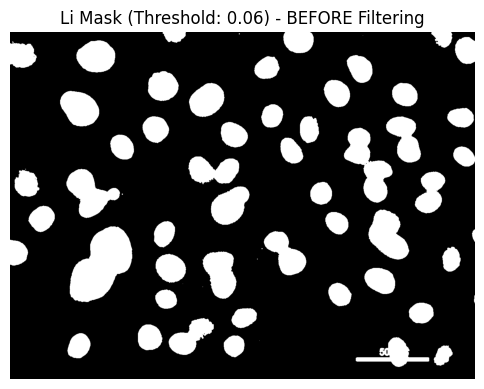

In [30]:
from skimage.measure import label, regionprops
# Cell 2: Li Thresholding and Initial Area Analysis

# Define the function provided in your request (corrected naming)
def analyze_cell_sizes(li_mask):
    # Labels erzeugen
    labeled_li = label(li_mask)

    # regionprops gibt die Eigenschaften jeder Region
    li_props = regionprops(labeled_li) # Corrected variable name from auto_li to li_props

    print(f"Detected Blobs (incl. Noise): {len(li_props)}")

    # Zellgrößen extrahieren
    li_areas = [r.area for r in li_props]

    if not li_areas:
        print("No areas detected. Analysis stopped.")
        return [], 0

    # Statistische Übersicht
    print("\n--- Blob Area Statistics (Pre-Filter) ---")
    print(f"Total Blobs: {len(li_areas)}")
    print(f"Min Area: {np.min(li_areas)}, Max Area: {np.max(li_areas)}, Average Area: {np.mean(li_areas):.2f}")

    return li_props, np.mean(li_areas) # Return properties and median for filtering


# 1. Apply Li Threshold
li_threshold_value = filters.threshold_li(blurred_image)
li_mask_initial = blurred_image > li_threshold_value

# 2. Analyze the initial mask
all_li_props, average_area = analyze_cell_sizes(li_mask_initial)

# 3. Visualize the initial mask
plt.figure(figsize=(6, 6))
plt.imshow(li_mask_initial, cmap='gray')
plt.title(f"Li Mask (Threshold: {li_threshold_value:.2f}) - BEFORE Filtering")
plt.axis('off')
plt.show()

Noise filtering

Average Area: 4795.19. Minimum Size Filter applied: 4795 pixels

--- Final Filtered Results ---
Objects Remaining (Cells): 21
Total Area Remaining: 191410.0


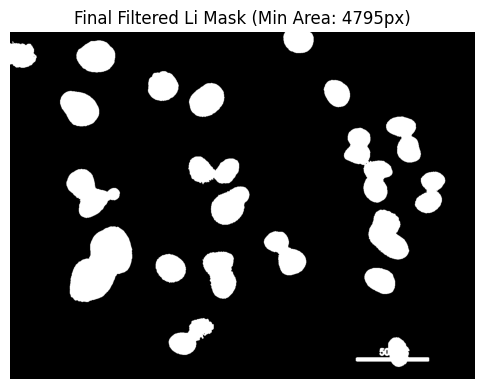

In [31]:
from skimage import morphology

# Cell 3: Noise Filtering and Final Visualization

if 'average_area' in locals() and average_area > 0:
    # Set the filter threshold: Use a fraction of the median area to define noise.
    # We choose 10% of the median area as the minimum size to keep.
    # NOTE: You must inspect the area statistics from Cell 2 and adjust this '0.1' factor if needed!
    min_size_threshold = int(average_area)

    print(f"Average Area: {average_area:.2f}. Minimum Size Filter applied: {min_size_threshold} pixels")

    #Remove small objects (noise)
    li_mask_filtered = morphology.remove_small_objects(
        li_mask_initial.astype(bool),
        min_size=min_size_threshold
    )

    #Final analysis of the filtered regions
    labeled_final = label(li_mask_filtered)
    final_props = regionprops(labeled_final)

    print(f"\n--- Final Filtered Results ---")
    print(f"Objects Remaining (Cells): {len(final_props)}")
    print(f"Total Area Remaining: {sum([r.area for r in final_props])}")

    plt.figure(figsize=(6, 6))
    plt.imshow(li_mask_filtered, cmap='gray')
    plt.title(f"Final Filtered Li Mask (Min Area: {min_size_threshold}px)")
    plt.axis('off')
    plt.show()

else:
    print("Filtering skipped: No objects detected or median area is zero.")

#### Setup, Load Image, and Pre-Processing (Local Normalization) of Red Channel Image

-0.010049830871928322


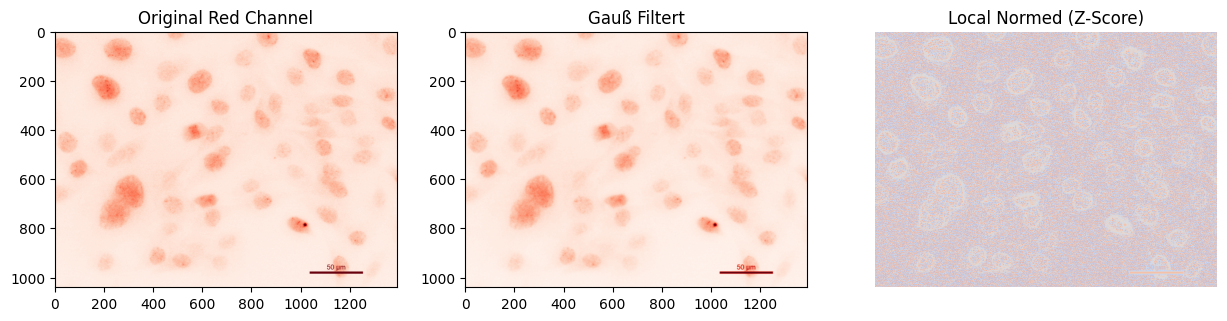

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from skimage import io, filters, measure, color
from skimage.filters import rank
from scipy import ndimage

#IMAGE_PATH = "data/Ex 3 day 1814/1_image_BGR- Red.tif"
IMAGE_PATH = "data/Ex 3 day 01/1_image_BGR- Red.tif"
WINDOW_SIZE = 5 #k×k-Fenster (z. B. 3×3, 5×5)
EPSILON = 1e-6


def load_red_channel(path):
    image = io.imread(path)

    if image.ndim == 3:
        #conversion to 8-Bit
        return (image[:, :, 0]).astype(np.uint8)
    elif image.ndim == 2:
         return image.astype(np.uint8)
    else:
        raise ValueError("Image must be 2D (grayscale) or 3D (color).")

def preprocess_and_normalize(img_red_raw, window_size, epsilon):

    #Apply Gauß filter
    #Sigma=1 is a little bit of smoothing
    img_red_smoothed = filters.gaussian(img_red_raw, sigma=1)

    #local average and standard deviation
    local_mean = ndimage.uniform_filter(img_red_smoothed, size=window_size)
    local_std = np.sqrt(ndimage.uniform_filter(img_red_smoothed**2, size=window_size) - local_mean**2)

    #Z-Score Normierung: (Pixel - lokaler Mittelwert) / (lokale Standardabweichung + Epsilon)
    img_red_norm = (img_red_smoothed - local_mean) / (local_std + epsilon)

    return img_red_norm, img_red_smoothed

try:
    img_red_raw = load_red_channel(IMAGE_PATH)
    img_red_norm, img_red_smoothed = preprocess_and_normalize(img_red_raw, WINDOW_SIZE, EPSILON)

    #Visualisation of norming
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(img_red_raw, cmap='Reds'); axs[0].set_title("Original Red Channel")
    axs[1].imshow(img_red_smoothed, cmap='Reds'); axs[1].set_title("Gauß Filtert")
    axs[2].imshow(img_red_norm, cmap='coolwarm'); axs[2].set_title("Local Normed (Z-Score)")
    print(np.mean(img_red_norm))
    axs[2].axis('off')
    plt.show()



except Exception as e:
    print(f"Fehler beim Laden/Verarbeiten des Bildes: {e}. Bitte Pfad prüfen.")

#### Masked Visualization after Blur in Red

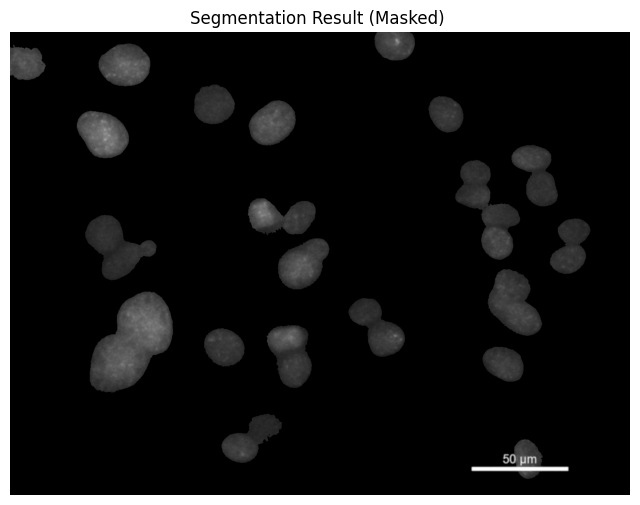

In [33]:
smoothed_intensity = img_red_smoothed.astype(np.float32)

# Black out the background (where li_mask_filtered = False)
masked_result = smoothed_intensity * li_mask_filtered

plt.figure(figsize=(8, 8))
plt.imshow(masked_result, cmap='gray', vmin=0, vmax=1)
plt.title(f"Segmentation Result (Masked) ")
plt.axis('off')
plt.show()

## ------ Foci Detection ------

Total Cells: 21
Total Foci: 64
   cell_id  peak_id  global_x  global_y  intensity_mean  intensity_peak  \
0        1        1       869        22            0.47        0.556986   
1        1        2       859         0            0.36        0.417282   

   foci_radius_pixels  foci_area_approx  cell_area image_id  
0                6.13        117.980003       5084           
1                2.83         25.129999       5084           


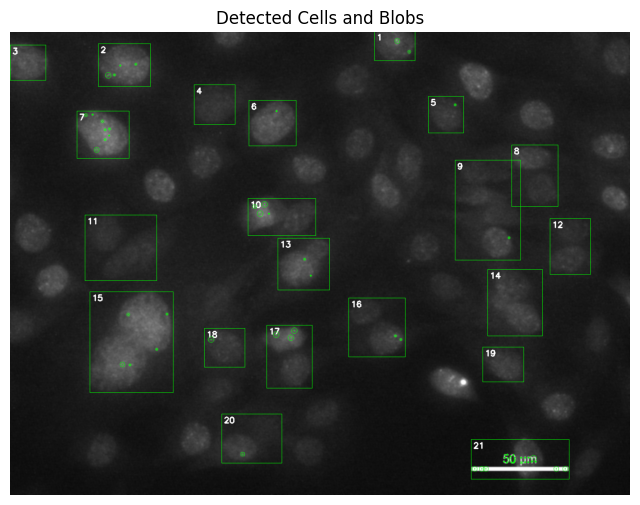

In [34]:
import numpy as np
import cv2
import pandas as pd
from skimage import io, measure, feature
import matplotlib.pyplot as plt
from skimage.draw import disk

#Find Cells

cell_mask = masked_result > 0
labeled_cells = measure.label(cell_mask)
regions = measure.regionprops(labeled_cells, smoothed_intensity)

intensity_image_uint8 = (smoothed_intensity * 255).astype(np.uint8)
output_image = cv2.cvtColor(intensity_image_uint8, cv2.COLOR_GRAY2BGR)
foci_records = []
peak_id_counter = 1

#Annotation and Foci Detection Loop
for region in regions:
    #Skip tiny noise
    if region.area < 50:
        continue

    #Get cell bounding box (row min/max, col min/max)
    minr, minc, maxr, maxc = region.bbox

    #Draw Cell Bounding Box (Green)
    cv2.rectangle(output_image, (minc, minr), (maxc, maxr), (0, 255, 0), 1)

    #Add Cell Label
    cv2.putText(output_image, str(region.label), (minc + 5, minr + 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    #Extract the local intensity data for the current cell region
    cropped_intensity = smoothed_intensity[minr:maxr, minc:maxc]

    #Blob Detection --- Laplacian of Gaussian
    #Find bright blobs and estimate their size (sigma)
    #The returned array is [row, column, sigma]
    blobs_log = feature.blob_log(
        cropped_intensity,
        min_sigma=2,    #Smallest expected focus size (size in pixels)
        max_sigma=5,   #Largest expected focus size
        num_sigma=10,
        threshold=0.05   #Lower threshold detects fainter foci; between 0 and 1
    )

    #Convert sigma to radius (radius = sigma * sqrt(2))
    blobs_log[:, 2] = blobs_log[:, 2] * np.sqrt(2)

    #Annotate and Record Foci
    for local_r, local_c, radius in blobs_log:
        local_r, local_c = int(local_r), int(local_c)

        # Convert local coordinates back to global image coordinates
        global_r = minr + local_r
        global_c = minc + local_c

        # Check if the blob center is actually inside the segmented cell mask
        if labeled_cells[global_r, global_c] != region.label:
            continue

        #Annotation: Center
        cv2.circle(output_image, (global_c, global_r), 1, (0, 255, 0), -1)

        #Annotation: estimated radius
        cv2.circle(output_image, (global_c, global_r), int(radius), (0, 255, 0), 1)

        #Use the calculated radius to define the focus area
        focus_radius = int(round(radius))

        #Create coordinates for the focus disk centered at (global_r, global_c)
        rr, cc = disk((global_r, global_c), focus_radius, shape=smoothed_intensity.shape)

        #Extract the intensities from the image that fall within the disk coordinates
        focus_intensities = smoothed_intensity[rr, cc]

        #Calculate the mean intensity over the focus area
        intensity_mean = np.mean(focus_intensities)

        #Data Collection
        foci_records.append({
            "cell_id": region.label,
            "peak_id": peak_id_counter,
            "global_x": global_c,
            "global_y": global_r,
            "intensity_mean": round(intensity_mean, 2),
            "intensity_peak": smoothed_intensity[global_r, global_c],
            "foci_radius_pixels": round(radius, 2),
            "foci_area_approx": round(np.pi * (radius**2), 2),
            "cell_area": round(region.area),
            "image_id":""  #Empty for now; wo only analyze one image ToDo: find way to extract name from folder for each image
        })
        peak_id_counter += 1

#Convert Records to DataFrame
df = pd.DataFrame(foci_records)
csv_path = "output/cell_foci_log_analysis.csv"
df.to_csv(csv_path, index=False)

print(f"Total Cells: {len(regions)}")
print(f"Total Foci: {len(foci_records)}")
print(df.head(2))

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Cells and Blobs")
plt.axis("off")
plt.show()

Total Cells: 21
Total Foci: 3548
   cell_id  peak_id  global_x  global_y  intensity_mean  intensity_peak  \
0        1        1       888        34            0.46        1.397986   
1        1        2       893        18            0.52        2.062160   

   foci_radius_pixels  foci_area_approx  cell_area image_id  
0                2.83         25.129999       5084           
1                2.83         25.129999       5084           


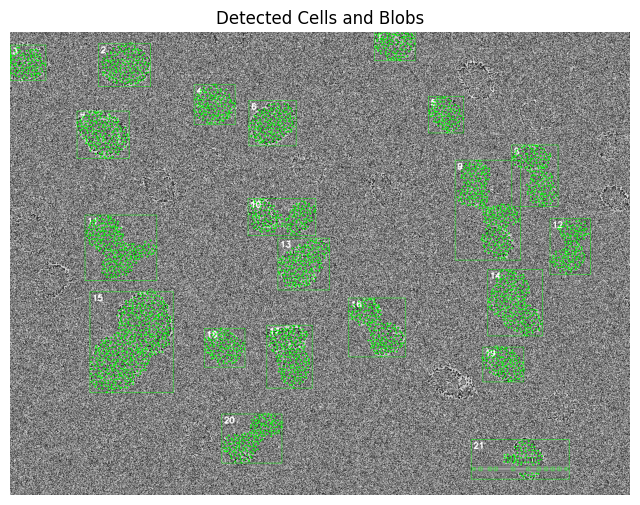

In [35]:
import numpy as np
import cv2
import pandas as pd
from skimage import io, measure, feature
import matplotlib.pyplot as plt
from skimage.draw import disk

#Find Cells
smoothed_intensity = img_red_norm.astype(np.float32)
cell_mask = masked_result > 0
labeled_cells = measure.label(cell_mask)
regions = measure.regionprops(labeled_cells, smoothed_intensity)

intensity_image_uint8 = (smoothed_intensity * 255).astype(np.uint8)
output_image = cv2.cvtColor(intensity_image_uint8, cv2.COLOR_GRAY2BGR)
foci_records = []
peak_id_counter = 1

#Annotation and Foci Detection Loop
for region in regions:
    #Skip tiny noise
    if region.area < 50:
        continue

    #Get cell bounding box (row min/max, col min/max)
    minr, minc, maxr, maxc = region.bbox

    #Draw Cell Bounding Box (Green)
    cv2.rectangle(output_image, (minc, minr), (maxc, maxr), (0, 255, 0), 1)

    #Add Cell Label
    cv2.putText(output_image, str(region.label), (minc + 5, minr + 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    #Extract the local intensity data for the current cell region
    cropped_intensity = smoothed_intensity[minr:maxr, minc:maxc]

    #Blob Detection --- Laplacian of Gaussian
    #Find bright blobs and estimate their size (sigma)
    #The returned array is [row, column, sigma]
    blobs_log = feature.blob_log(
        cropped_intensity,
        min_sigma=2,    #Smallest expected focus size (size in pixels)
        max_sigma=5,   #Largest expected focus size
        num_sigma=10,
        threshold=0.05   #Lower threshold detects fainter foci; between 0 and 1
    )

    #Convert sigma to radius (radius = sigma * sqrt(2))
    blobs_log[:, 2] = blobs_log[:, 2] * np.sqrt(2)

    #Annotate and Record Foci
    for local_r, local_c, radius in blobs_log:
        local_r, local_c = int(local_r), int(local_c)

        # Convert local coordinates back to global image coordinates
        global_r = minr + local_r
        global_c = minc + local_c

        # Check if the blob center is actually inside the segmented cell mask
        if labeled_cells[global_r, global_c] != region.label:
            continue

        #Annotation: Center
        cv2.circle(output_image, (global_c, global_r), 1, (0, 255, 0), -1)

        #Annotation: estimated radius
        cv2.circle(output_image, (global_c, global_r), int(radius), (0, 255, 0), 1)

        #Use the calculated radius to define the focus area
        focus_radius = int(round(radius))

        #Create coordinates for the focus disk centered at (global_r, global_c)
        rr, cc = disk((global_r, global_c), focus_radius, shape=smoothed_intensity.shape)

        #Extract the intensities from the image that fall within the disk coordinates
        focus_intensities = smoothed_intensity[rr, cc]

        #Calculate the mean intensity over the focus area
        intensity_mean = np.mean(focus_intensities)

        #Data Collection
        foci_records.append({
            "cell_id": region.label,
            "peak_id": peak_id_counter,
            "global_x": global_c,
            "global_y": global_r,
            "intensity_mean": round(intensity_mean, 2),
            "intensity_peak": smoothed_intensity[global_r, global_c],
            "foci_radius_pixels": round(radius, 2),
            "foci_area_approx": round(np.pi * (radius**2), 2),
            "cell_area": round(region.area),
            "image_id":""  #Empty for now; wo only analyze one image ToDo: find way to extract name from folder for each image
        })
        peak_id_counter += 1

#Convert Records to DataFrame
df = pd.DataFrame(foci_records)
csv_path = "output/cell_foci_log_analysis.csv"
df.to_csv(csv_path, index=False)

print(f"Total Cells: {len(regions)}")
print(f"Total Foci: {len(foci_records)}")
print(df.head(2))

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Cells and Blobs")
plt.axis("off")
plt.show()